# Testing GPU

## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
def normalized_sequence_to_images(sequence):
  return (sequence + 1) * 127.5 

In [3]:
def plot_sample_sequence(sample_sequence):
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(sample_sequence):
        ax = fig.add_subplot(2,10,i+1)
        ax.imshow(im, cmap='gray') 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 4 and sample_sequence.shape[0] == 1:
        plot_sample_sequence(inverse_sequence_generator(sample_sequence[0]))
    else:
        raise ValueError("The tensor must be of shape (1, height, width, channels)")

In [4]:


def ratio_std(previous, current):
  ratio = tf.math.divide_no_nan(current, previous)
  ratio = tf.reshape(ratio, [ratio.shape[0], ratio.shape[1]*ratio.shape[2]])
  return tf.math.reduce_std(ratio, axis=1)

def ratio_mean(previous, current):
  ratio = tf.math.divide_no_nan(current, previous)
  ratio = tf.reshape(ratio, [ratio.shape[0], ratio.shape[1]*ratio.shape[2]])
  return tf.math.reduce_mean(ratio, axis=1)

def ratio_sequences(previous, current):
  ratio = current/previous
  return tf.where(tf.math.is_nan(ratio), 0., ratio)


def pixel_difference_loss(previous, current):
  return  tf.math.abs(current-previous)

def absolute_difference(previous, current):
  diff =  tf.math.abs(current-previous)
  diff = tf.reshape(diff, [diff.shape[0], diff.shape[1]*diff.shape[2]])
  return tf.math.reduce_mean(diff, axis=1)

def custom_loss_sum(y_true, y_pred, loss_function):
  mean_pred = []
  mean_true = []
  for i in range(1, y_true.shape[-1]):
    mean_pred.append(loss_function(y_pred[...,i-1], y_pred[...,i]))
    mean_true.append(loss_function(y_true[...,i-1], y_true[...,i]))
  mean_pred = tf.convert_to_tensor(mean_pred, dtype=tf.float32)
  mean_true = tf.convert_to_tensor(mean_true, dtype=tf.float32)
  return tf.math.reduce_sum(tf.abs(mean_true - mean_pred))

def custom_loss_mean(y_true, y_pred, loss_function):
  mean_pred = []
  mean_true = []
  for i in range(1, y_true.shape[-1]):
    mean_pred.append(loss_function(y_pred[...,i-1], y_pred[...,i]))
    mean_true.append(loss_function(y_true[...,i-1], y_true[...,i]))
  mean_pred = tf.convert_to_tensor(mean_pred, dtype=tf.float32)
  mean_true = tf.convert_to_tensor(mean_true, dtype=tf.float32)
  return tf.math.reduce_mean(tf.abs(mean_true - mean_pred))

In [5]:
def get_sequence(sequence_number, sequences):
    current_sequence = sequences[:,sequence_number,...]
    current_sequence = current_sequence.astype(np.float32)
    current_sequence = np.expand_dims(current_sequence, axis=-1)
    current_sequence = np.moveaxis(current_sequence, -1, 0)
    current_sequence = np.moveaxis(current_sequence, 1, -1)
    return current_sequence

def move_pixels(sequence, number_of_pixels=1):
    s1 = np.roll(sequence, number_of_pixels, axis=1)
    s2 = np.roll(sequence, -number_of_pixels, axis=1)
    s3 = np.roll(sequence, number_of_pixels, axis=2)
    s4 = np.roll(sequence, -number_of_pixels, axis=2)
    return s1, s2, s3, s4

In [6]:
PATH = Path('/home/rafa/Sync/data/mnist_test_seq.npy')
sequences = np.load(PATH)

(1, 64, 64, 20)


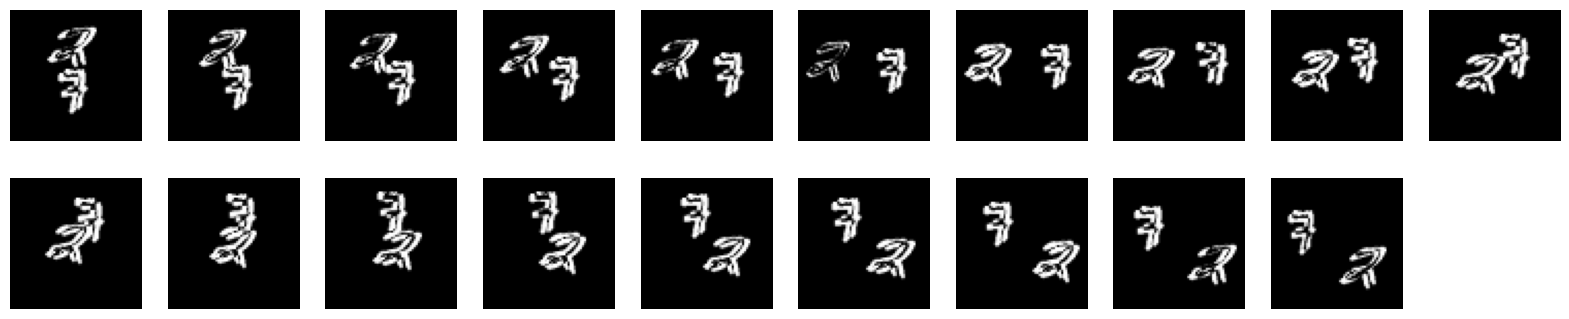

In [9]:
a = get_sequence(0, sequences)
b = get_sequence(1, sequences)

# print("Originals")
# plot_sequence_from_tensor(a)
# plot_sequence_from_tensor(b)
# print("Difference")
# plot_sequence_from_tensor(a-a)
# plot_sequence_from_tensor(a-b)
# print("Absolute difference")
# plot_sequence_from_tensor(tf.math.abs(a-a))
# plot_sequence_from_tensor(tf.math.abs(a-b))
# print("ratio")
# plot_sequence_from_tensor(np.absolute(np.nan_to_num(a/a)))
# plot_sequence_from_tensor(np.absolute(np.nan_to_num(a/b)))
# plot_sequence_from_tensor(np.absolute(np.nan_to_num(b/a)))
# print("ratio2")
# plot_sequence_from_tensor(tf.math.divide_no_nan(a,a))
# plot_sequence_from_tensor(tf.math.divide_no_nan(a,b))
# plot_sequence_from_tensor(tf.math.divide_no_nan(b,a))
# print("ratio3")
# plot_sequence_from_tensor(ratio_sequences(a,a))
# plot_sequence_from_tensor(ratio_sequences(a,b))
# plot_sequence_from_tensor(ratio_sequences(b,a))
# print("diff ex")
print(a.shape)
plot_sequence_from_tensor(tf.math.abs(a[...,:-1]-a[...,1:]))




In [8]:
sequences = normalize(sequences)

Originals


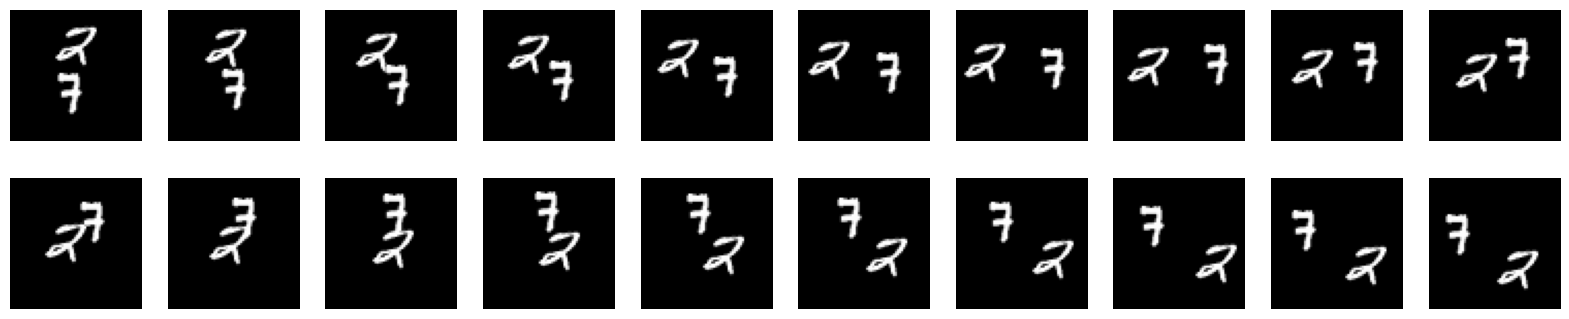

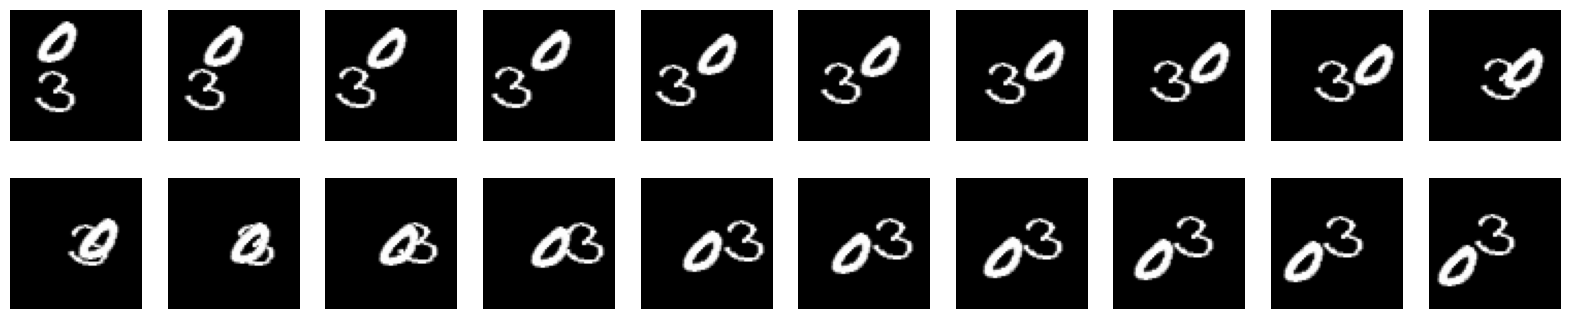

Difference


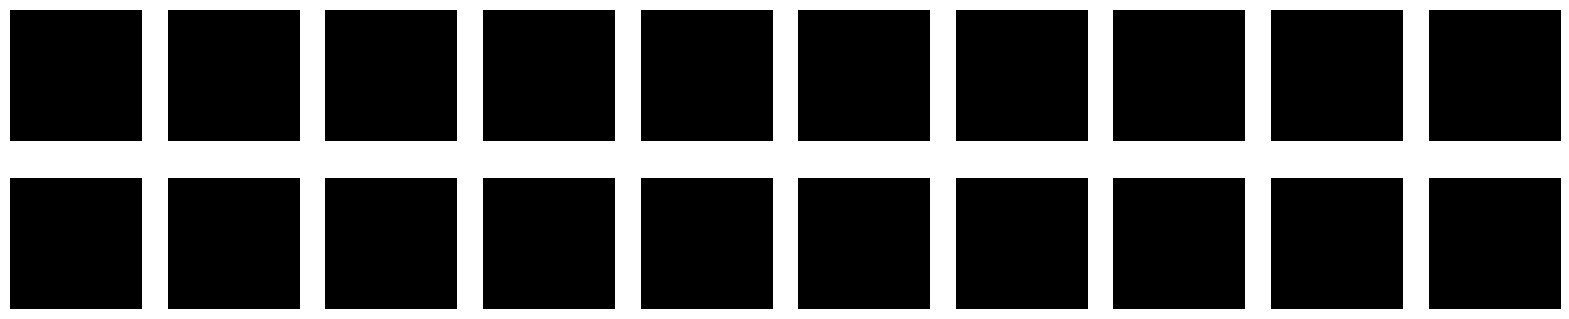

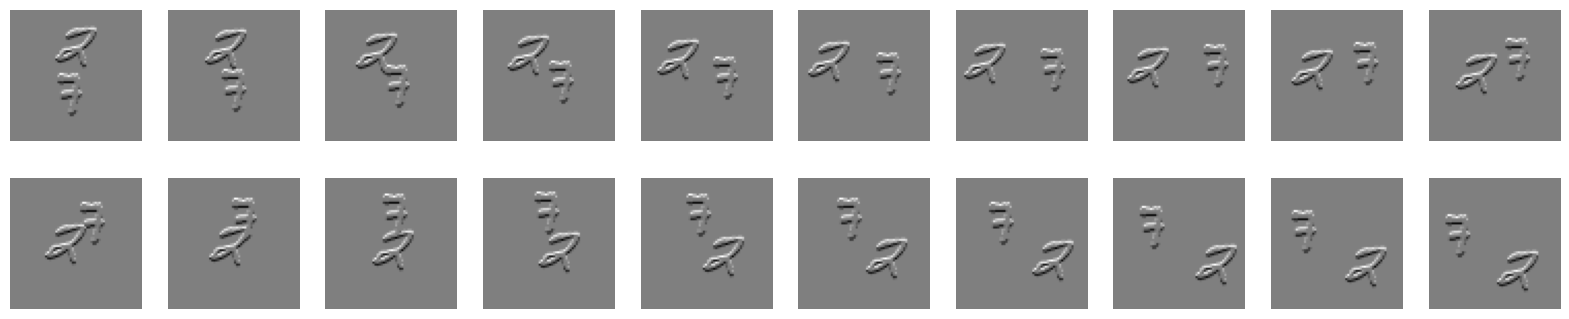

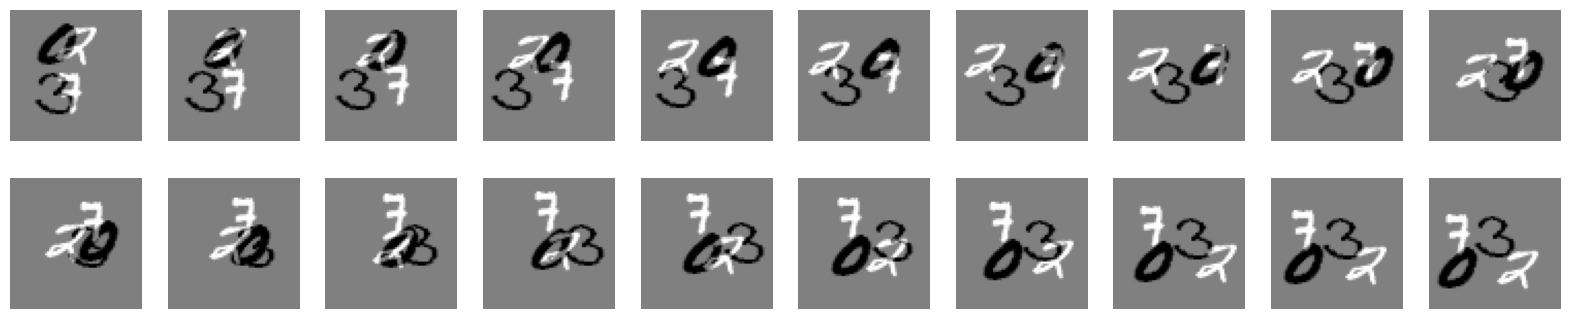

Absolute difference


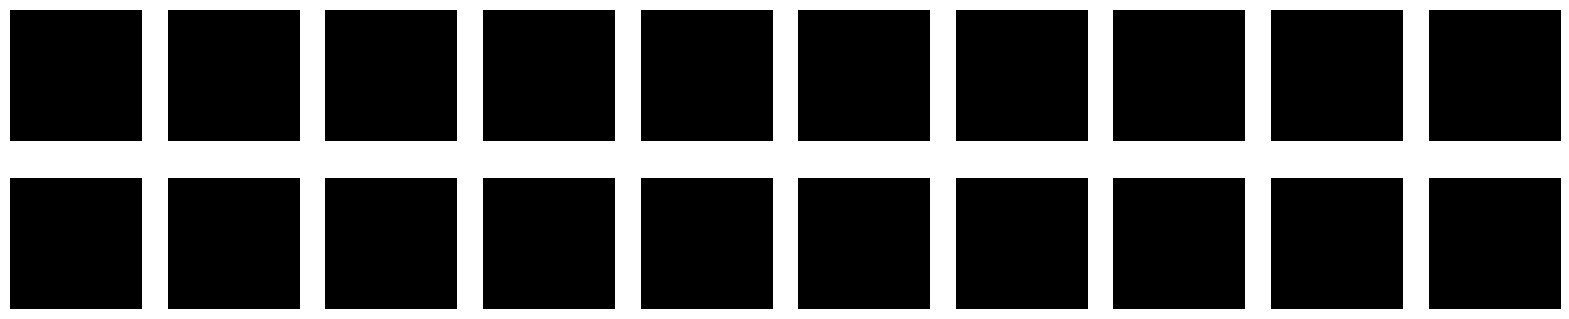

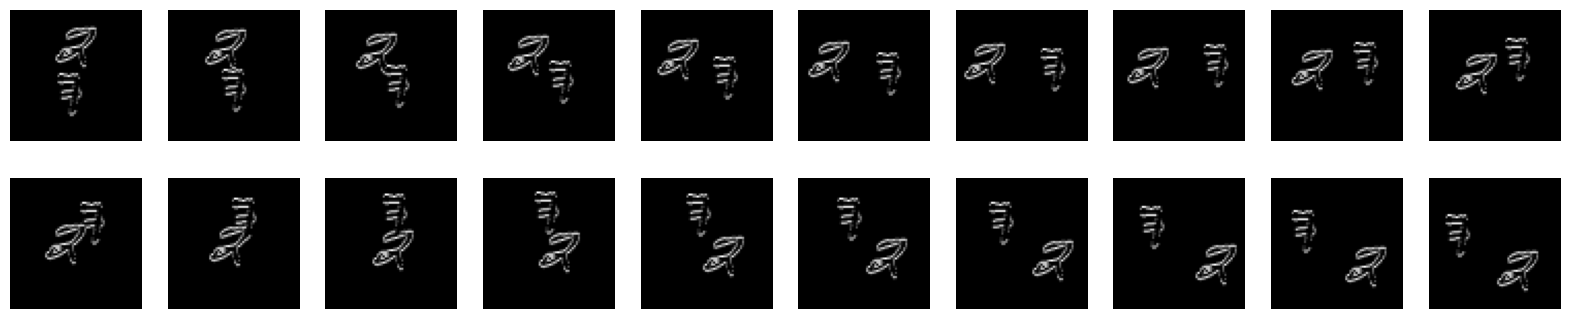

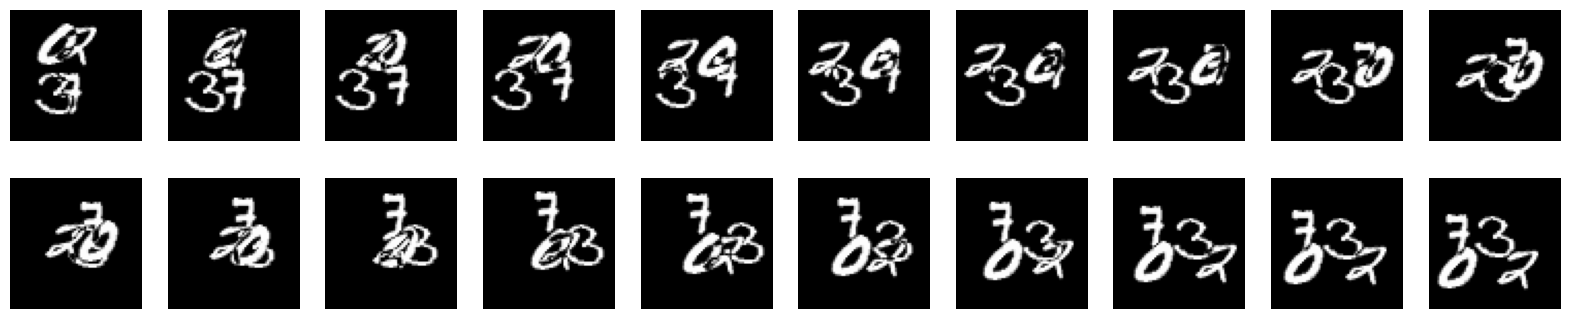

ratio


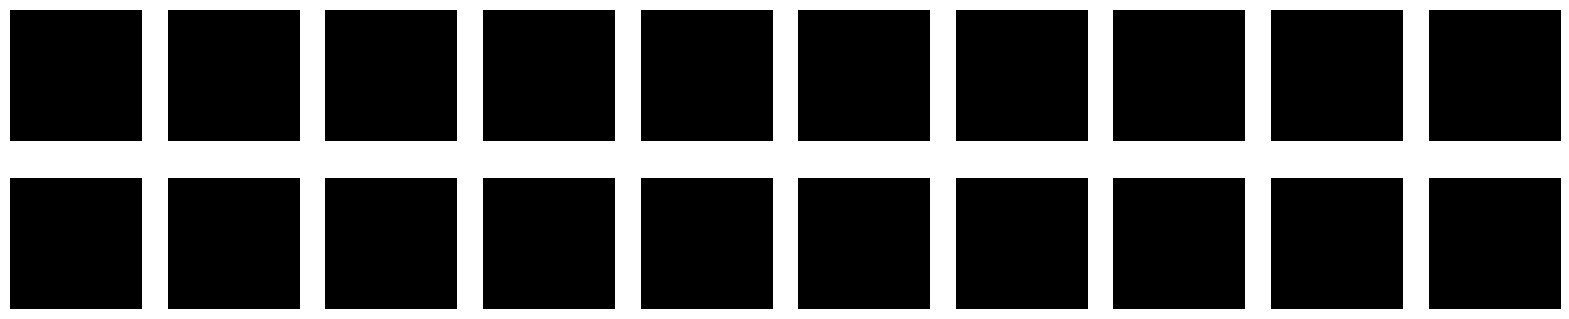

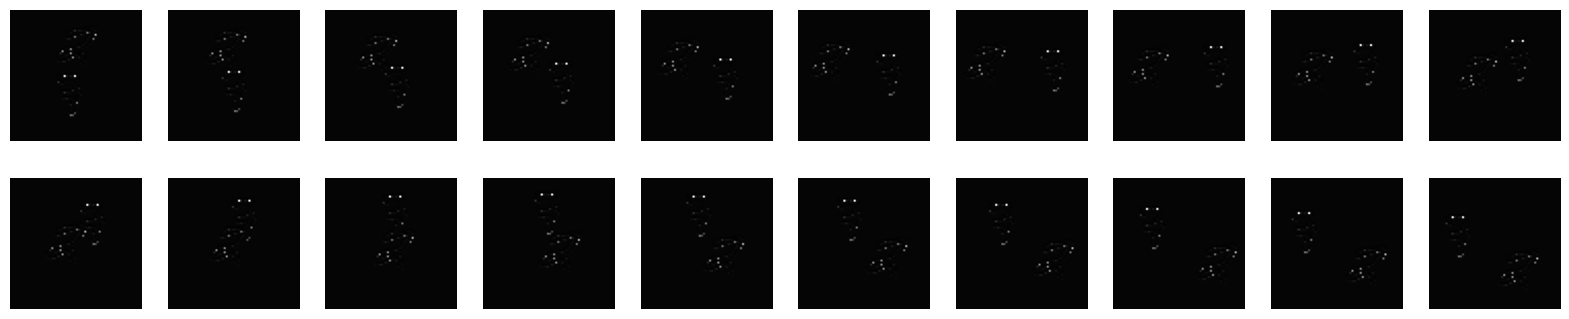

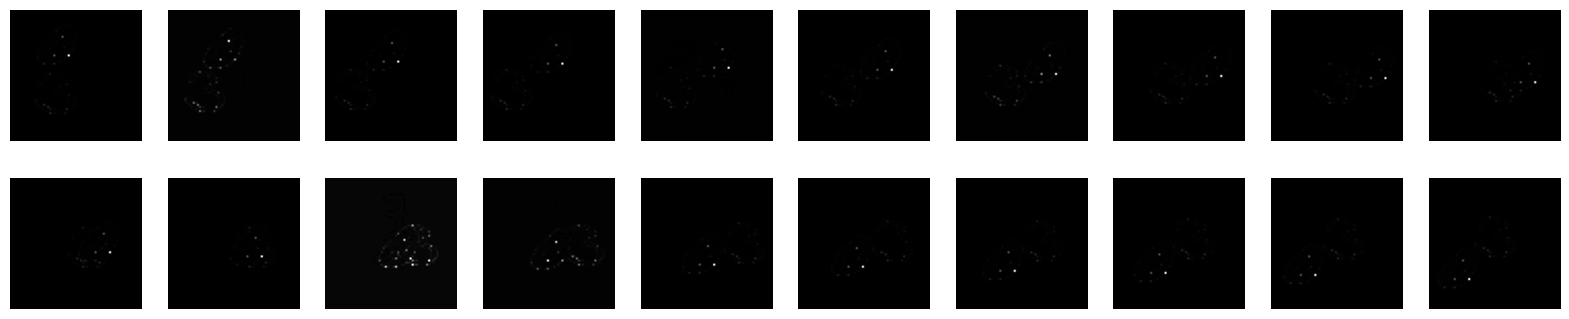

In [9]:
a = get_sequence(0, sequences)
b = get_sequence(1, sequences)

a1, a2, a3, a4 = move_pixels(a)
b1, b2, b3, b4 = move_pixels(b)

print("Originals")
plot_sequence_from_tensor(a)
plot_sequence_from_tensor(b)
print("Difference")
plot_sequence_from_tensor(a-a)
plot_sequence_from_tensor(a-a1)
plot_sequence_from_tensor(a-b1)
print("Absolute difference")
plot_sequence_from_tensor(tf.math.abs(a-a))
plot_sequence_from_tensor(tf.math.abs(a-a1))
plot_sequence_from_tensor(tf.math.abs(a-b1))
print("ratio")
plot_sequence_from_tensor(tf.math.abs(tf.math.divide_no_nan(a, a)))
plot_sequence_from_tensor(tf.math.abs(tf.math.divide_no_nan(a, a1)))
plot_sequence_from_tensor(tf.math.abs(tf.math.divide_no_nan(a, b1)))

In [10]:
# indice permutation of an array
print(np.arange(20))
idx = np.random.permutation(20)
idx = np.random.permutation(idx)

print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)
idx = np.random.permutation(idx)
print(idx)




[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[10  6 17 12  1 13  2  8  0 19  9 14  4  7 11 18 15  3 16  5]
[14  7 11  0  6 16  4 18  8  3 10 15 17 12  2  5 19  1  9 13]
[ 9  5  7 12  4 10 18 19  2  6 16 17  3 15 14 11  0  8  1 13]
[ 4  8 13  5  0  6  3  7 19  1 10  2  9 18 15 11 14 12 17 16]
[ 3  9 18  0 19  7 13 17 10  5  8  4 11 12 15 14  6  2  1 16]
[17 15  8  4  5  1  9  2 18 16 19  6  3 10 12  7 11  0 13 14]


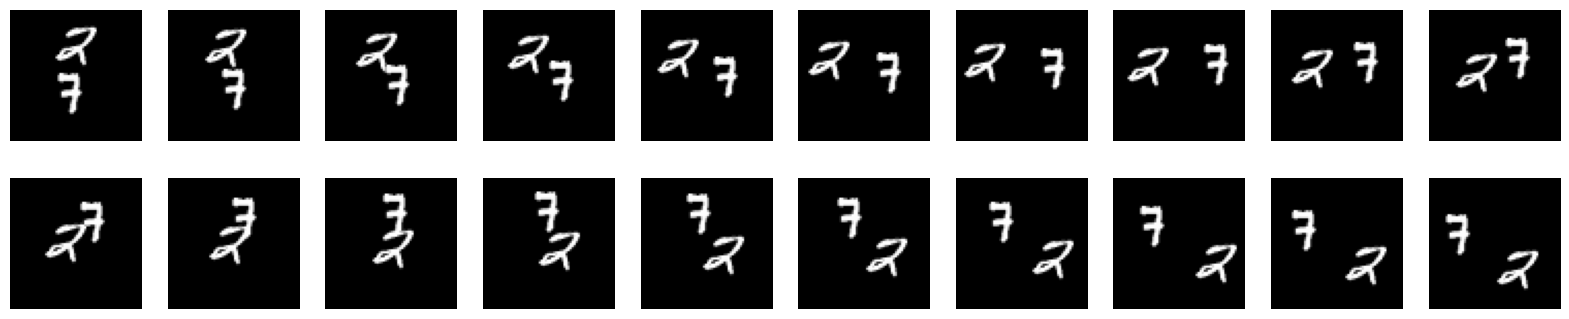

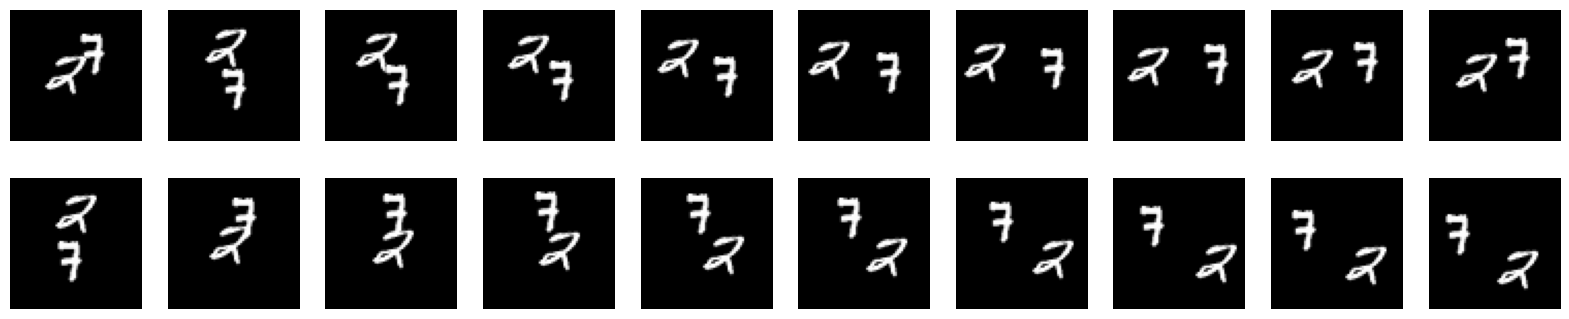

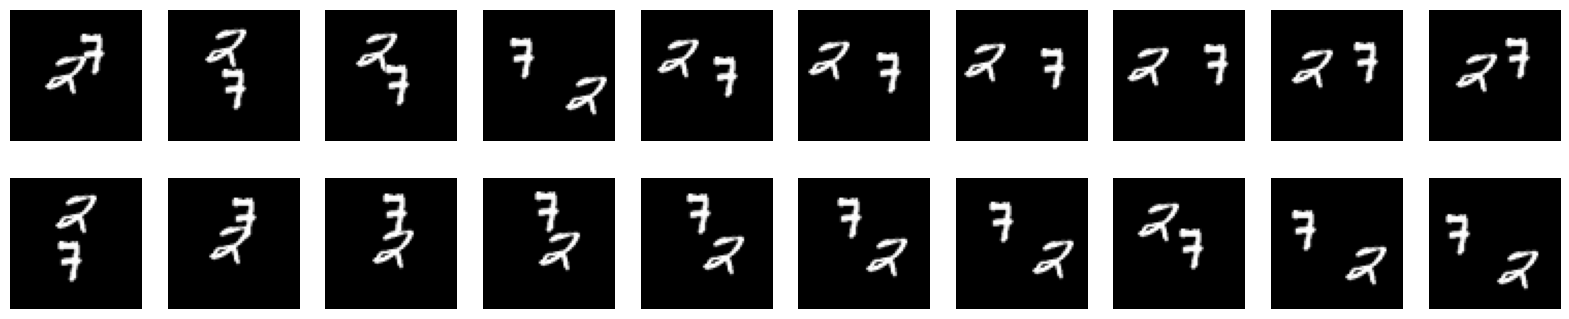

In [11]:
c1 = a[...,[10,1,2,3,4,5,6,7,8,9,0,11,12,13,14,15,16,17,18,19]]
c2 = a[...,[10,1,2,17,4,5,6,7,8,9,0,11,12,13,14,15,16,3,18,19]]
c3 = a[...,[10,1,2,17,4,12,6,7,8,9,0,11,5,13,14,15,16,3,18,19]]
c4 = a[...,[10,1,2,17,4,12,6,7,8,18,0,11,5,13,14,15,16,3,9,19]]
c5 = a[...,[8,18,16,7,10,0,4,14,15,17,19,6,13,1,12,2,3,5,11,9]]

plot_sequence_from_tensor(a)
plot_sequence_from_tensor(c1)
plot_sequence_from_tensor(c2)

In [12]:
print("a, a")
print(custom_loss_sum(a, a,ratio_mean))
print("a, c1")
print(custom_loss_sum(a, c1,ratio_mean))
print("a, c2")
print(custom_loss_sum(a, c2,ratio_mean))
print("a, c3")
print(custom_loss_sum(a, c3,ratio_mean))
print("a, c4")
print(custom_loss_sum(a, c4,ratio_mean))
print("a, c5")
print(custom_loss_sum(a, c5,ratio_mean))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.11287016, shape=(), dtype=float32)
a, c2
tf.Tensor(0.28152698, shape=(), dtype=float32)
a, c3
tf.Tensor(0.6058801, shape=(), dtype=float32)
a, c4
tf.Tensor(0.78082937, shape=(), dtype=float32)
a, c5
tf.Tensor(0.8182319, shape=(), dtype=float32)


In [13]:
print("a, a")
print(custom_loss_sum(a, a,absolute_difference))
print("a, c1")
print(custom_loss_sum(a, c1,absolute_difference))
print("a, c2")
print(custom_loss_sum(a, c2,absolute_difference))
print("a, c3")
print(custom_loss_sum(a, c3,absolute_difference))
print("a, c4")
print(custom_loss_sum(a, c4,absolute_difference))
print("a, c5")
print(custom_loss_sum(a, c5,absolute_difference))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.06939912, shape=(), dtype=float32)
a, c2
tf.Tensor(0.1970454, shape=(), dtype=float32)
a, c3
tf.Tensor(0.47544995, shape=(), dtype=float32)
a, c4
tf.Tensor(0.6201268, shape=(), dtype=float32)
a, c5
tf.Tensor(0.6366805, shape=(), dtype=float32)


In [14]:
print("a, a")
print(custom_loss_sum(a, a, ratio_std))
print("a, c1")
print(custom_loss_sum(a, c1, ratio_std))
print("a, c2")
print(custom_loss_sum(a, c2, ratio_std))
print("a, c3")
print(custom_loss_sum(a, c3, ratio_std))
print("a, c4")
print(custom_loss_sum(a, c4, ratio_std))
print("a, c5")
print(custom_loss_sum(a, c5, ratio_std))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.6493666, shape=(), dtype=float32)
a, c2
tf.Tensor(1.5071981, shape=(), dtype=float32)
a, c3
tf.Tensor(2.7820268, shape=(), dtype=float32)
a, c4
tf.Tensor(3.0176978, shape=(), dtype=float32)
a, c5
tf.Tensor(4.078028, shape=(), dtype=float32)


In [15]:
print("a, a")
print(custom_loss_mean(a, a, ratio_sequences))
print("a, c1")
print(custom_loss_mean(a, c1, ratio_sequences))
print("a, c2")
print(custom_loss_mean(a, c2, ratio_sequences))
print("a, c3")
print(custom_loss_mean(a, c3, ratio_sequences))
print("a, c4")
print(custom_loss_mean(a, c4, ratio_sequences))
print("a, c5")
print(custom_loss_mean(a, c5, ratio_sequences))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.055958264, shape=(), dtype=float32)
a, c2
tf.Tensor(0.13297223, shape=(), dtype=float32)
a, c3
tf.Tensor(0.21663551, shape=(), dtype=float32)
a, c4
tf.Tensor(0.28457627, shape=(), dtype=float32)
a, c5
tf.Tensor(0.52617246, shape=(), dtype=float32)


In [16]:
print("a, a")
print(custom_loss_mean(a, a, pixel_difference_loss))
print("a, c1")
print(custom_loss_mean(a, c1, pixel_difference_loss))
print("a, c2")
print(custom_loss_mean(a, c2, pixel_difference_loss))
print("a, c3")
print(custom_loss_mean(a, c3, pixel_difference_loss))
print("a, c4")
print(custom_loss_mean(a, c4, pixel_difference_loss))
print("a, c5")
print(custom_loss_mean(a, c5, pixel_difference_loss))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.023076808, shape=(), dtype=float32)
a, c2
tf.Tensor(0.05637608, shape=(), dtype=float32)
a, c3
tf.Tensor(0.09599448, shape=(), dtype=float32)
a, c4
tf.Tensor(0.12821156, shape=(), dtype=float32)
a, c5
tf.Tensor(0.24571724, shape=(), dtype=float32)


In [17]:
def l1_loss(a, b):
    return tf.reduce_mean(tf.abs(a - b))
print("a, a")
print(l1_loss(a, a))
print("a, c1")
print(l1_loss(a, c1))
print("a, c2")
print(l1_loss(a, c2))
print("a, c3")
print(l1_loss(a, c3))
print("a, c4")
print(l1_loss(a, c4))
print("a, c5")
print(l1_loss(a, c5))

a, a
tf.Tensor(0.0, shape=(), dtype=float32)
a, c1
tf.Tensor(0.015810164, shape=(), dtype=float32)
a, c2
tf.Tensor(0.03282954, shape=(), dtype=float32)
a, c3
tf.Tensor(0.053079236, shape=(), dtype=float32)
a, c4
tf.Tensor(0.07243011, shape=(), dtype=float32)
a, c5
tf.Tensor(0.18066387, shape=(), dtype=float32)
